In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df = pd.read_csv("/content/drive/MyDrive/AIML_lab_sem4/exp2,3,4/stock_price_with_price_column.csv")

In [3]:
df.head()

,Date,Stock,Open,High,Low,Close,Volume,Price
0,2020-01-01,AAPL,173.80,174.75,173.68,174.43,8204212,174.286667
1,2020-01-02,AAPL,176.01,177.59,174.07,177.55,2766891,176.403333
2,2020-01-03,AAPL,177.57,178.37,176.62,176.71,5721339,177.233333
3,2020-01-06,AAPL,176.01,177.58,171.33,171.73,9242680,173.546667
4,2020-01-07,AAPL,171.85,172.20,170.69,170.82,4416664,171.236667


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6525 entries, 0 to 6524
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    6525 non-null   object 
 1   Stock   6525 non-null   object 
 2   Open    6525 non-null   float64
 3   High    6525 non-null   float64
 4   Low     6525 non-null   float64
 5   Close   6525 non-null   float64
 6   Volume  6525 non-null   int64  
 7   Price   6525 non-null   float64
dtypes: float64(5), int64(1), object(2)
memory usage: 407.9+ KB


In [7]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df = df.reset_index(drop=True)


In [9]:
df_encoded = pd.get_dummies(df, columns=['Stock'],drop_first=True)


In [11]:
def create_lag_features(data, lag=5):
    df_lag = data.copy()
    stock_cols = [col for col in data.columns if col.startswith('Stock_')]

    for i in range(1, lag + 1):
        df_lag[f'lag_{i}'] = (df_lag.groupby(stock_cols)['Price'].shift(i))
    return df_lag

df_lag = create_lag_features(df_encoded, lag=5)
df_lag.dropna(inplace=True)


In [12]:
X = df_lag.drop(['Date', 'Price'], axis=1)
y = df_lag['Price']

split_index = int(len(df_lag) * 0.8)

X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]


In [13]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()


In [14]:
model.fit(X_train, y_train)


LinearRegression()

In [22]:
y_pred = model.predict(X_test)
y_pred


array([194.79333333, 226.06333333, 246.99      , ..., 216.85333333,
       222.22      , 218.07      ])

In [18]:
from sklearn.metrics import mean_absolute_error,  r2_score

print("MAE :", mean_absolute_error(y_test, y_pred))
print("R2  :", r2_score(y_test, y_pred))


MAE : 1.2766876649878284e-10
R2  : 1.0


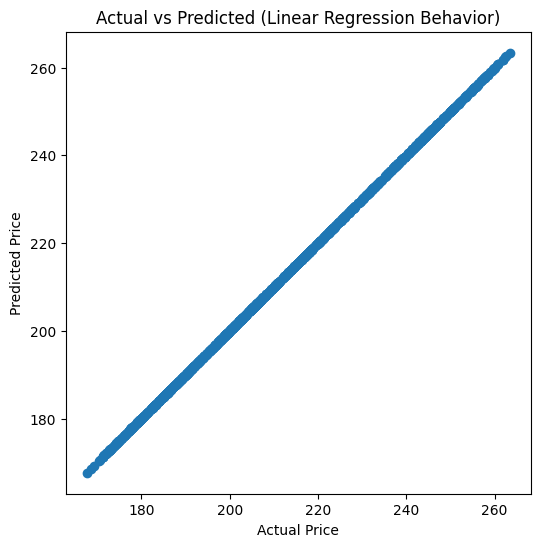

In [20]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6, 6))

# Scatter: actual vs predicted
plt.scatter(y_test, y_pred)

# Ideal linear line (y = x)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted (Linear Regression Behavior)")

plt.show()


In [21]:
corr = df.corr(numeric_only=True)
display(corr)

,Open,High,Low,Close,Volume,Price
Open,1.000000,0.999589,0.999579,0.999010,0.002314,0.999543
High,0.999589,1.000000,0.999485,0.999576,0.001795,0.999837
Low,0.999579,0.999485,1.000000,0.999590,0.002654,0.999842
Close,0.999010,0.999576,0.999590,1.000000,0.001975,0.999872
Volume,0.002314,0.001795,0.002654,0.001975,1.000000,0.002141
Price,0.999543,0.999837,0.999842,0.999872,0.002141,1.000000


In [ ]:
import pickle

In [ ]:

with open('/content/drive/MyDrive/AIML_lab_sem4/exp2,3,4/stocks_model.pkl', 'wb') as file:
    pickle.dump(model, file)

print("Model saved successfully to '/content/drive/MyDrive/AIML_lab_sem4/exp2,3,4/stocks_model.pkl'")

Model saved successfully to '/content/drive/MyDrive/AIML_lab_sem4/exp2,3,4/stocks_model.pkl'
